In [1]:
import kagglehub

path = kagglehub.dataset_download("yeanzc/telco-customer-churn-ibm-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'telco-customer-churn-ibm-dataset' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn-ibm-dataset


Male/Female to binary
Paperless Billing to binary

In [2]:
import pandas as pd

telco = pd.read_excel(path+"/Telco_customer_churn.xlsx")
telco.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [3]:
telco.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [4]:
telco.dtypes

,0
CustomerID,object
Count,int64
Country,object
State,object
City,object
Zip Code,int64
Lat Long,object
Latitude,float64
Longitude,float64
Gender,object


In [5]:
telco["Churn Reason"].value_counts()

,count
Churn Reason,
Attitude of support person,192
Competitor offered higher download speeds,189
Competitor offered more data,162
Don't know,154
Competitor made better offer,140
Attitude of service provider,135
Competitor had better devices,130
Network reliability,103
Product dissatisfaction,102


In [6]:
telco["Churn Reason"].fillna("Don't know", inplace=True)

/tmp/ipython-input-155144961.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  telco["Churn Reason"].fillna("Don't know", inplace=True)


In [7]:
telco["Churn Reason"].isna().sum()

np.int64(0)

In [8]:
telco["Churn Reason"].value_counts()

,count
Churn Reason,
Don't know,5328
Attitude of support person,192
Competitor offered higher download speeds,189
Competitor offered more data,162
Competitor made better offer,140
Attitude of service provider,135
Competitor had better devices,130
Network reliability,103
Product dissatisfaction,102


In [9]:
object_cols = telco.select_dtypes(include='object').columns
cols_with_empty_strings = [col for col in object_cols if (telco[col] == '').any()]

print("Columns with empty strings:", cols_with_empty_strings)

Columns with empty strings: []


In [10]:
len(telco)

7043

In [11]:
telco.duplicated().any()

np.False_

In [12]:
telco.select_dtypes(include='number').describe(include="all")

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [13]:
telco.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [14]:
telco["Churn Score"]

,Churn Score
0,86
1,67
2,86
3,84
4,89
...,...
7038,45
7039,59
7040,71
7041,59


In [15]:
telco[(telco["Tenure Months"] > 24) & (telco["Churn Score"] == "Yes")]

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason


In [16]:
telco["Total Charges"] = pd.to_numeric(telco["Total Charges"], errors="coerce")

In [17]:
telco[(telco["Total Charges"] > 0) & (telco["Tenure Months"] == 0)]

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason


In [18]:
sum(telco["Monthly Charges"] < 0)

0

In [20]:
import numpy as np

min(telco["CLTV"]), max(telco["CLTV"]), np.std(telco["CLTV"])

(2003, 6500, 1182.9731608159996)

In [21]:
telco["CLTV"].describe()

,CLTV
count,7043.000000
mean,4400.295755
std,1183.057152
min,2003.000000
25%,3469.000000
50%,4527.000000
75%,5380.500000
max,6500.000000


These columns contain post-outcome information and will be excluded from predictive modeling to avoid leakage.

- Churn Label
- Churn Score
- Churn Reason
- Possibility CLTV

Distribution & Imbalance Check

Churn rate

Revenue distribution

Tenure distribution

CLTV skewness

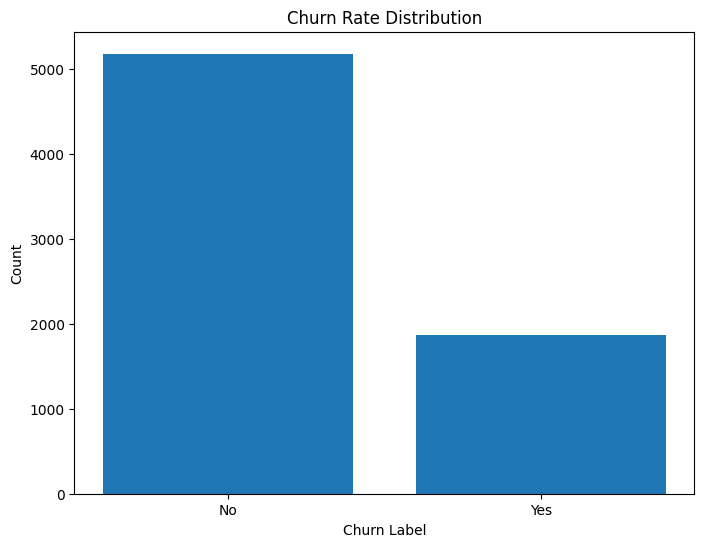

In [30]:
import matplotlib.pyplot as plt

churn_counts = telco["Churn Label"].value_counts()

fig, ax = plt.subplots(figsize=(8, 6))

ax.bar(churn_counts.index, churn_counts.values)

ax.set_title("Churn Rate Distribution")
ax.set_xlabel("Churn Label")
ax.set_ylabel("Count")

plt.show()

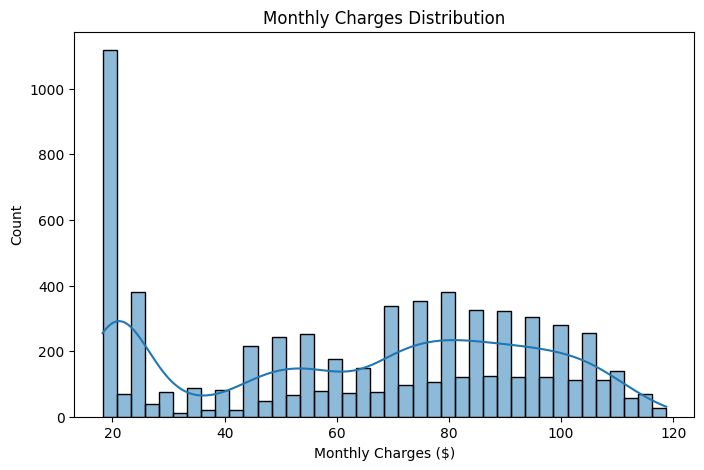

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df_val = telco.copy()

df_val["Total Charges"] = pd.to_numeric(df_val["Total Charges"], errors="coerce")

plt.figure(figsize=(8,5))
sns.histplot(df_val["Monthly Charges"], bins=40, kde=True)
plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges ($)")
plt.ylabel("Count")
plt.show()

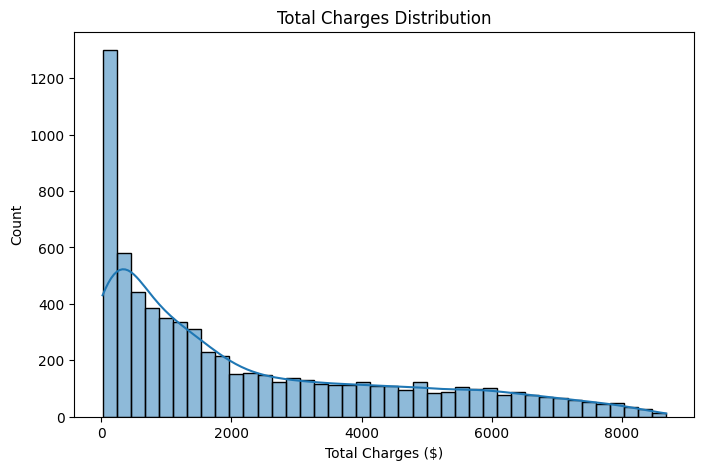

In [25]:
plt.figure(figsize=(8,5))
sns.histplot(df_val["Total Charges"].dropna(), bins=40, kde=True)
plt.title("Total Charges Distribution")
plt.xlabel("Total Charges ($)")
plt.ylabel("Count")
plt.show()

In [31]:
# CLTV Skewness Check

In [35]:
telco["CLTV"].describe()

,CLTV
count,7043.000000
mean,4400.295755
std,1183.057152
min,2003.000000
25%,3469.000000
50%,4527.000000
75%,5380.500000
max,6500.000000


In [37]:
Q1 = np.percentile(telco["CLTV"], 25)
Q3 = np.percentile(telco["CLTV"], 75)

np.median(telco["CLTV"]), (Q1+Q3)/2

(np.float64(4527.0), np.float64(4424.75))

In [38]:
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

lower, upper

(np.float64(601.75), np.float64(8247.75))

In [41]:
outliers = []

for cltv in telco["CLTV"]:
  if lower > cltv > upper:
    print(cltv)
    outliers.append(cltv)